# Fine-tuning một mô hình embedding `BAAI/bge-m3` cho truy xuất văn bản pháp luật tiếng Việt

## 0. Mục tiêu bài toán

Bài toán được mô hình hóa như một bài toán **retrieval/ranking** trong hệ thống truy xuất văn bản pháp luật tiếng Việt. Với một câu hỏi pháp luật `query`, mô hình embedding cần mã hóa `query` và các đoạn văn bản/câu trả lời pháp luật `passage` vào cùng một không gian vector.

Sau khi có vector, điểm liên quan giữa query và passage được tính bằng cosine similarity:

```text
score(query, passage) = cosine(embedding(query), embedding(passage))
```

Trong pipeline RAG, embedding model đóng vai trò **retriever bước đầu**: lấy ra top-k văn bản ứng viên từ corpus lớn trước khi chuyển sang reranker hoặc LLM.

Notebook này fine-tune **một mô hình duy nhất**: `BAAI/bge-m3`. Ngoài kết quả fine-tuned, notebook có thêm phần so sánh với **baseline pretrained** của cùng mô hình trước khi fine-tune. Validation/test dùng **TF-IDF hard negatives** để đánh giá khó hơn random negatives và gần hơn với tình huống truy xuất thực tế.

## 1. Cài đặt thư viện

In [1]:
# Gỡ torchvision để tránh lỗi import transformers trong môi trường Colab/Python 3.12.
# Bài toán này là NLP nên không cần torchvision.
!pip uninstall -y torchvision

# Pin transformers/sentence-transformers để hạn chế lỗi import trong Colab.
!pip install -U torch "transformers==4.44.2" "sentence-transformers==3.2.1" datasets accelerate scikit-learn tqdm pandas sentencepiece protobuf matplotlib

## 2. Import thư viện

Nếu runtime đã từng lỗi ở cell import `transformers` hoặc `sentence_transformers`, hãy chọn **Runtime → Restart runtime**, rồi chạy lại notebook từ đầu.

In [2]:
import os
import sys
import subprocess
import gc
import json
import math
import random
import ast
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.util import batch_to_device
from transformers import get_linear_schedule_with_warmup, set_seed

print("Imports OK")

Imports OK


## 3. Mount Google Drive và thiết lập thư mục làm việc

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_DIR = "/content/drive/MyDrive"
    PROJECT_DIR = "/content/drive/MyDrive/Project_ML"

    if not os.path.exists(DRIVE_DIR):
        raise RuntimeError("Không tìm thấy Google Drive sau khi mount.")

except Exception as e:
    print("Chi tiết:", e)
    PROJECT_DIR = os.getcwd()

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Project dir:", PROJECT_DIR)

Mounted at /content/drive
Project dir: /content/drive/MyDrive/Project_ML


## 4. Cấu hình thí nghiệm

Tỷ lệ chia dữ liệu được đặt là **70/15/15** cho Train/Validation/Test.

- **Train 70%**: đủ lớn để fine-tune mô hình theo miền pháp luật.
- **Validation 15%**: dùng để theo dõi learning curve, early stopping và chọn checkpoint tốt nhất.
- **Test 15%**: giữ riêng để đánh giá cuối cùng, hạn chế rò rỉ thông tin trong quá trình huấn luyện.

In [4]:
# ===== Cấu hình chính =====
MODEL_NAME = "BAAI/bge-m3"
OUTPUT_PATH = "./vietlaw-bge-m3-finetuned"
BEST_MODEL_PATH = os.path.join(OUTPUT_PATH, "best")
ARTIFACT_DIR = "./embedding_report_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Chia dữ liệu theo yêu cầu báo cáo: Train / Validation / Test.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-9

# Với embedding model, MAX_SEQ_LENGTH áp dụng riêng cho từng text:
# query riêng, passage riêng. Không phải tổng query + passage như reranker cross-encoder.
MAX_SEQ_LENGTH = 512

# Cấu hình huấn luyện
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 2
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
USE_AMP = torch.cuda.is_available()

# Evaluation ranking: 1 positive + EVAL_NEGATIVES_PER_QUERY TF-IDF hard negatives.
EVAL_ENCODE_BATCH_SIZE = 64
EVAL_QUERY_BATCH_SIZE = 32
EVAL_NEGATIVES_PER_QUERY = 31
EVAL_TFIDF_TOP_K_POOL = 100

# Baseline là BAAI/bge-m3 pretrained trước khi fine-tune.
RUN_BASELINE_EVAL = True

# Log train và validation đồng bộ theo step.
# Ví dụ EPOCHS=2 và LOG_EVALS_PER_EPOCH=4 thì learning curve có khoảng 8 điểm validation.
LOG_EVALS_PER_EPOCH = 4

# Early stopping dựa trên validation MRR@10 trên hard negatives.
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_THRESHOLD = 0.0005

# Không giới hạn số lượng mẫu ở các tập.
# Đặt một số nguyên nếu chỉ muốn debug nhanh; để None là dùng toàn bộ dữ liệu.
MAX_TRAIN_QUERIES = None
MAX_VALIDATION_QUERIES = None
MAX_TEST_QUERIES = None

# Không giới hạn số lượng query dùng để đánh giá validation/test.
MAX_VAL_EVAL_QUERIES = 2000
MAX_TEST_EVAL_QUERIES = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Thiết bị:", DEVICE)
print("Mixed precision:", USE_AMP)
print("Tỷ lệ chia dữ liệu:", {"train": TRAIN_SIZE, "validation": VAL_SIZE, "test": TEST_SIZE})
print("Validation/test negatives:", "TF-IDF hard negatives")
print("Giới hạn dữ liệu:", {
    "MAX_TRAIN_QUERIES": MAX_TRAIN_QUERIES,
    "MAX_VALIDATION_QUERIES": MAX_VALIDATION_QUERIES,
    "MAX_TEST_QUERIES": MAX_TEST_QUERIES,
    "MAX_VAL_EVAL_QUERIES": MAX_VAL_EVAL_QUERIES,
    "MAX_TEST_EVAL_QUERIES": MAX_TEST_EVAL_QUERIES,
})

Thiết bị: cuda
Mixed precision: True
Tỷ lệ chia dữ liệu: {'train': 0.7, 'validation': 0.15, 'test': 0.15}
Validation/test negatives: TF-IDF hard negatives
Giới hạn dữ liệu: {'MAX_TRAIN_QUERIES': None, 'MAX_VALIDATION_QUERIES': None, 'MAX_TEST_QUERIES': None, 'MAX_VAL_EVAL_QUERIES': 2000, 'MAX_TEST_EVAL_QUERIES': None}


## 5. Tải và chuẩn hóa dữ liệu

Ba nguồn dữ liệu được chuẩn hóa về cùng schema:

| Trường | Ý nghĩa |
|---|---|
| `query` | Câu hỏi pháp luật |
| `pos` | Đoạn văn bản/câu trả lời đúng |
| `source` | Nguồn dataset |

In [5]:
def _clean_text(x) -> str:
    if x is None:
        return ""
    if isinstance(x, (list, tuple)):
        x = " ".join([str(i) for i in x])
    x = str(x).replace(" ", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x


def _parse_generated_qa_pairs(value):
    # Dataset thangvip thường là list[dict], nhưng hàm này cũng xử lý trường hợp bị lưu dạng string.
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            return json.loads(value)
        except Exception:
            pass
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def load_adamwhite625():
    print("Đang tải dataset: adamwhite625/vietnam-legal-qa...")
    try:
        ds = load_dataset("adamwhite625/vietnam-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("question", ""))
            a = _clean_text(row.get("law_content", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "adamwhite625/vietnam-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải adamwhite625/vietnam-legal-qa: {e}")
        return []


def load_huyydangg():
    print("Đang tải dataset: huyydangg/LEGAL-EVAL-Dataset...")
    try:
        ds = load_dataset("huyydangg/LEGAL-EVAL-Dataset", split="test")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("anchor", ""))
            a = _clean_text(row.get("positive", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "huyydangg/LEGAL-EVAL-Dataset"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải huyydangg/LEGAL-EVAL-Dataset: {e}")
        return []


def load_thangvip():
    print("Đang tải dataset: thangvip/vietnamese-legal-qa...")
    try:
        ds = load_dataset("thangvip/vietnamese-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            qa_pairs = _parse_generated_qa_pairs(row.get("generated_qa_pairs", []))
            if not isinstance(qa_pairs, list):
                continue
            for pair in qa_pairs:
                if not isinstance(pair, dict):
                    continue
                q = _clean_text(pair.get("question", ""))
                a = _clean_text(pair.get("answer", ""))
                if q and a and len(a) > 50:
                    standardized_data.append({"query": q, "pos": a, "source": "thangvip/vietnamese-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải thangvip/vietnamese-legal-qa: {e}")
        return []


def deduplicate_pairs(data: List[Dict[str, str]]) -> List[Dict[str, str]]:
    seen = set()
    deduped = []
    for item in data:
        q = _clean_text(item.get("query"))
        p = _clean_text(item.get("pos"))
        key = (q.lower(), p.lower())
        if q and p and key not in seen:
            seen.add(key)
            deduped.append({**item, "query": q, "pos": p})
    return deduped

In [6]:
data1 = load_adamwhite625()
data2 = load_huyydangg()
data3 = load_thangvip()

raw_data = data1 + data2 + data3
all_data = deduplicate_pairs(raw_data)

if len(all_data) == 0:
    raise RuntimeError("Không tải được dữ liệu. Hãy kiểm tra kết nối mạng hoặc tên dataset.")


def normalize_text(text: str) -> str:
    return " ".join(str(text).strip().lower().split())


def split_by_passage_group(
    data: List[Dict[str, str]],
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
):
    """Chia dữ liệu theo nhóm positive passage để giảm leakage giữa Train/Validation/Test."""
    rng = random.Random(seed)

    passage_groups = {}
    for item in data:
        passage_key = normalize_text(item["pos"])
        passage_groups.setdefault(passage_key, []).append(item)

    groups = list(passage_groups.values())
    rng.shuffle(groups)

    n_total = len(data)
    n_train_target = int(n_total * train_size)
    n_val_target = int(n_total * val_size)
    targets = {
        "train": n_train_target,
        "validation": n_val_target,
        "test": n_total - n_train_target - n_val_target,
    }

    splits = {"train": [], "validation": [], "test": []}
    for group in groups:
        best_split = min(
            splits.keys(),
            key=lambda name: len(splits[name]) / max(targets[name], 1),
        )
        splits[best_split].extend(group)

    for name in splits:
        rng.shuffle(splits[name])

    return splits["train"], splits["validation"], splits["test"]


train_data, validation_data, test_data = split_by_passage_group(
    all_data,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

if MAX_TRAIN_QUERIES is not None:
    train_data = train_data[:MAX_TRAIN_QUERIES]
if MAX_VALIDATION_QUERIES is not None:
    validation_data = validation_data[:MAX_VALIDATION_QUERIES]
if MAX_TEST_QUERIES is not None:
    test_data = test_data[:MAX_TEST_QUERIES]

eval_val_data = validation_data[:MAX_VAL_EVAL_QUERIES] if MAX_VAL_EVAL_QUERIES is not None else validation_data
eval_test_data = test_data[:MAX_TEST_EVAL_QUERIES] if MAX_TEST_EVAL_QUERIES is not None else test_data

n_total = len(all_data)

print(f"Tổng số cặp trước deduplicate: {len(raw_data):,}")
print(f"Tổng số cặp sau deduplicate: {len(all_data):,}")
print(f"Train: {len(train_data):,} | Validation: {len(validation_data):,} | Test: {len(test_data):,}")
print(f"Validation dùng để eval: {len(eval_val_data):,} | Test dùng để eval: {len(eval_test_data):,}")

split_summary = pd.DataFrame([
    {"Split": "Train", "Samples": len(train_data), "Ratio": len(train_data) / n_total, "Vai trò": "Huấn luyện mô hình"},
    {"Split": "Validation", "Samples": len(validation_data), "Ratio": len(validation_data) / n_total, "Vai trò": "Theo dõi learning curve, early stopping, chọn checkpoint"},
    {"Split": "Test", "Samples": len(test_data), "Ratio": len(test_data) / n_total, "Vai trò": "Đánh giá cuối cùng"},
])
print("Bảng 1. Tỷ lệ chia dữ liệu Train/Validation/Test")
display(split_summary)
split_summary.to_csv(os.path.join(ARTIFACT_DIR, "table_1_split_summary.csv"), index=False, encoding="utf-8-sig")

source_summary = (
    pd.DataFrame(all_data)
    .groupby("source")
    .size()
    .reset_index(name="Samples")
    .sort_values("Samples", ascending=False)
)
source_summary["Ratio"] = source_summary["Samples"] / source_summary["Samples"].sum()
print("Bảng 2. Phân bố mẫu theo nguồn dữ liệu")
display(source_summary)
source_summary.to_csv(os.path.join(ARTIFACT_DIR, "table_2_source_summary.csv"), index=False, encoding="utf-8-sig")

train_queries = {normalize_text(x["query"]) for x in train_data}
val_queries = {normalize_text(x["query"]) for x in validation_data}
test_queries = {normalize_text(x["query"]) for x in test_data}
train_passages = {normalize_text(x["pos"]) for x in train_data}
val_passages = {normalize_text(x["pos"]) for x in validation_data}
test_passages = {normalize_text(x["pos"]) for x in test_data}

overlap_summary = pd.DataFrame([
    {"Loại overlap": "Train-Val query", "Số lượng": len(train_queries & val_queries)},
    {"Loại overlap": "Train-Test query", "Số lượng": len(train_queries & test_queries)},
    {"Loại overlap": "Val-Test query", "Số lượng": len(val_queries & test_queries)},
    {"Loại overlap": "Train-Val passage", "Số lượng": len(train_passages & val_passages)},
    {"Loại overlap": "Train-Test passage", "Số lượng": len(train_passages & test_passages)},
    {"Loại overlap": "Val-Test passage", "Số lượng": len(val_passages & test_passages)},
])
print("Bảng 3. Kiểm tra overlap giữa các tập dữ liệu")
display(overlap_summary)
overlap_summary.to_csv(os.path.join(ARTIFACT_DIR, "table_3_overlap_summary.csv"), index=False, encoding="utf-8-sig")

Đang tải dataset: adamwhite625/vietnam-legal-qa...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/850 [00:00<?, ?B/s]

ready_to_import_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4837 [00:00<?, ? examples/s]

...

,Split,Samples,Ratio,Vai trò
0,Train,26446,0.70,Huấn luyện mô hình
1,Validation,5667,0.15,"Theo dõi learning curve, early stopping, chọn ..."
2,Test,5667,0.15,Đánh giá cuối cùng


Bảng 2. Phân bố mẫu theo nguồn dữ liệu


,source,Samples,Ratio
2,thangvip/vietnamese-legal-qa,29137,0.771228
0,adamwhite625/vietnam-legal-qa,4837,0.128031
1,huyydangg/LEGAL-EVAL-Dataset,3806,0.100741


Bảng 3. Kiểm tra overlap giữa các tập dữ liệu


,Loại overlap,Số lượng
0,Train-Val query,5
1,Train-Test query,6
2,Val-Test query,1
3,Train-Val passage,0
4,Train-Test passage,0
5,Val-Test passage,0


### 5.1. Tiền xử lý dữ liệu

Các bước tiền xử lý chính:

1. Chuẩn hóa text: bỏ khoảng trắng thừa, thay non-breaking space.
2. Chuẩn hóa schema về `query`, `pos`, `source`.
3. Parse trường `generated_qa_pairs` ở dataset `thangvip/vietnamese-legal-qa`.
4. Lọc mẫu rỗng và passage quá ngắn.
5. Deduplicate theo cặp `(query, pos)`.
6. Chia train/validation/test theo nhóm positive passage để giảm overlap dữ liệu.
7. Tạo TF-IDF hard negatives cho validation/test.

In [7]:
def add_length_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["query_chars"] = df["query"].str.len()
    df["passage_chars"] = df["pos"].str.len()
    df["query_words"] = df["query"].str.split().str.len()
    df["passage_words"] = df["pos"].str.split().str.len()
    return df

length_df = add_length_columns(pd.DataFrame(all_data))
length_summary = length_df[["query_chars", "passage_chars", "query_words", "passage_words"]].describe().T

print("Bảng 4. Thống kê độ dài query/passage")
display(length_summary)
length_summary.to_csv(os.path.join(ARTIFACT_DIR, "table_4_length_summary.csv"), encoding="utf-8-sig")

Bảng 4. Thống kê độ dài query/passage


,count,mean,std,min,25%,50%,75%,max
query_chars,37780.0,198.850635,98.257922,14.0,128.00,181.0,253.0,949.0
passage_chars,37780.0,814.659873,1168.933411,55.0,352.75,636.0,1050.0,93874.0
query_words,37780.0,44.564558,22.290507,4.0,29.00,41.0,57.0,209.0
passage_words,37780.0,179.722155,255.076717,11.0,78.00,141.0,232.0,20460.0


## 5.2. Tạo TF-IDF hard negatives cho Validation/Test

Validation và Test không dùng random negatives. Với mỗi query, notebook lấy các passage có độ tương đồng TF-IDF cao nhất nhưng không phải positive passage. Đây là nhóm negative khó hơn vì chúng thường có nhiều từ khóa gần với query, giúp đánh giá mô hình sát với tình huống retrieval thực tế hơn.

In [8]:
def random_negatives_for_index(
    idx: int,
    data: List[Dict[str, str]],
    num_negatives: int,
    rng: random.Random,
) -> List[str]:
    pos = data[idx]["pos"]
    n = len(data)
    negatives = []
    attempts = 0
    while len(negatives) < num_negatives and attempts < 500:
        j = rng.randrange(n)
        candidate = data[j]["pos"]
        if j != idx and candidate != pos and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    if len(negatives) < num_negatives:
        for j, item in enumerate(data):
            candidate = item["pos"]
            if j != idx and candidate != pos and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break
    return negatives


def build_tfidf_negatives(
    data: List[Dict[str, str]],
    num_negatives: int,
    top_k_pool: int = 100,
    seed: int = 42,
    batch_size: int = 128,
    desc: str = "TF-IDF hard negatives",
) -> List[List[str]]:
    """Sinh hard negatives bằng TF-IDF."""
    rng = random.Random(seed)
    queries = [x["query"] for x in data]
    passages = [x["pos"] for x in data]
    n = len(data)

    if n <= 1:
        return [[] for _ in data]

    print(f"Đang fit TF-IDF trên {n:,} passages để tạo {desc}...")
    vectorizer = TfidfVectorizer(
        lowercase=True,
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    doc_matrix = vectorizer.fit_transform(passages)
    query_matrix = vectorizer.transform(queries)

    all_negatives = []
    k = min(top_k_pool + 1, n)

    for start in tqdm(range(0, n, batch_size), desc=desc):
        end = min(start + batch_size, n)
        sims = query_matrix[start:end].dot(doc_matrix.T).toarray()

        for local_i, scores in enumerate(sims):
            idx = start + local_i
            pos = passages[idx]

            if k < n:
                candidate_idx = np.argpartition(-scores, kth=k - 1)[:k]
            else:
                candidate_idx = np.arange(n)

            candidate_idx = candidate_idx[np.argsort(-scores[candidate_idx])]

            negatives = []
            for j in candidate_idx:
                candidate = passages[int(j)]
                if int(j) != idx and candidate != pos and candidate not in negatives:
                    negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

            if len(negatives) < num_negatives:
                extra = random_negatives_for_index(idx, data, num_negatives - len(negatives), rng)
                for item in extra:
                    if item not in negatives:
                        negatives.append(item)
                    if len(negatives) == num_negatives:
                        break

            all_negatives.append(negatives)

    return all_negatives


val_ranking_negatives = build_tfidf_negatives(
    eval_val_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 23,
    desc="Validation ranking TF-IDF hard negatives",
)

test_ranking_negatives = build_tfidf_negatives(
    eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 29,
    desc="Test ranking TF-IDF hard negatives",
)

print("Ví dụ validation/test hard negatives:")
print("Query:", eval_test_data[0]["query"][:300])
print("Positive:", eval_test_data[0]["pos"][:300])
for i, neg in enumerate(test_ranking_negatives[0][:3], 1):
    print(f"Hard negative {i}:", neg[:300])

Đang fit TF-IDF trên 2,000 passages để tạo Validation ranking TF-IDF hard negatives...


Validation ranking TF-IDF hard negatives:   0%|          | 0/16 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5,667 passages để tạo Test ranking TF-IDF hard negatives...


Test ranking TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Ví dụ validation/test hard negatives:
Query: Công trình sửa chữa dưới 500 triệu có được thuê tư vấn?
Positive: Đơn vị tôi là đơn vị hành chính sự nghiệp thuộc UBND cấp huyện. Đơn vị tôi có sửa chữa công trình xây dựng có tổng dự toán sửa chữa dưới 500 triệu đồng và trên 100 triệu đồng. Khi được cấp có thẩm quyền thống nhất chủ trương cho đầu tư sửa chữa công trình xây dựng từ nguồn kinh phí thường xuyên và n
Hard negative 1: Theo điểm a khoản 1 Điều 57, văn bản đề nghị cấp giấy phép sửa chữa công cụ hỗ trợ đối với đối tượng không thuộc phạm vi quản lý của Bộ Quốc phòng phải ghi rõ các thông tin sau: 1. Tên và địa chỉ của cơ quan, tổ chức, doanh nghiệp có nhu cầu sửa chữa. 2. Tên và địa chỉ của tổ chức, doanh nghiệp sẽ t
Hard negative 2: Dựa trên Khoản 3, Điều 71 của Dự thảo Luật Giao thông đường bộ (sửa đổi) lần 3, sự khác biệt cơ bản giữa "sửa chữa định kỳ" và "sửa chữa đột xuất" đối với công trình đường bộ nằm ở mục đích, thời điểm và nguyên nhân phát sinh: 1. **Sửa chữa định kỳ (Kho

## 6. Lựa chọn mô hình và lý do

Mô hình được sử dụng trong notebook này là `BAAI/bge-m3`.

Lý do lựa chọn:

- Là mô hình embedding đa ngôn ngữ, phù hợp với tiếng Việt.
- Phù hợp cho bài toán retrieval trong pipeline RAG.
- Cho phép encode query và passage độc lập, thuận tiện xây dựng vector database.
- Có thể fine-tune bằng contrastive/ranking loss với dữ liệu dạng positive pairs.

Notebook chỉ thực hiện một mô hình. Phần so sánh với các mô hình khác sẽ do báo cáo nhóm tổng hợp sau.

## 7. Load model và mô tả kiến trúc

In [ ]:
print(f"Đang tải mô hình: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
model.max_seq_length = MAX_SEQ_LENGTH

try:
    base_config = model[0].auto_model.config
    hidden_size = getattr(base_config, "hidden_size", None)
    num_layers = getattr(base_config, "num_hidden_layers", None)
    num_heads = getattr(base_config, "num_attention_heads", None)
    activation = getattr(base_config, "hidden_act", None)
    vocab_size = getattr(base_config, "vocab_size", None)
    model_type = getattr(base_config, "model_type", None)
except Exception:
    hidden_size = num_layers = num_heads = activation = vocab_size = model_type = None

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_summary = pd.DataFrame([
    {"Thuộc tính": "Model name", "Giá trị": MODEL_NAME},
    {"Thuộc tính": "Model type", "Giá trị": model_type},
    {"Thuộc tính": "Max sequence length", "Giá trị": MAX_SEQ_LENGTH},
    {"Thuộc tính": "Hidden size", "Giá trị": hidden_size},
    {"Thuộc tính": "Hidden layers", "Giá trị": num_layers},
    {"Thuộc tính": "Attention heads", "Giá trị": num_heads},
    {"Thuộc tính": "Activation", "Giá trị": activation},
    {"Thuộc tính": "Vocabulary size", "Giá trị": vocab_size},
    {"Thuộc tính": "Total parameters", "Giá trị": f"{total_params:,}"},
    {"Thuộc tính": "Trainable parameters", "Giá trị": f"{trainable_params:,}"},
])

print("Bảng 5. Thông tin kiến trúc và số lượng tham số của mô hình embedding")
display(arch_summary)
arch_summary.to_csv(os.path.join(ARTIFACT_DIR, "table_5_arch_summary.csv"), index=False, encoding="utf-8-sig")

Đang tải mô hình: BAAI/bge-m3
Bảng 5. Thông tin kiến trúc và số lượng tham số của mô hình embedding


,Thuộc tính,Giá trị
0,Model name,BAAI/bge-m3
1,Model type,xlm-roberta
2,Max sequence length,512
3,Hidden size,1024
4,Hidden layers,24
5,Attention heads,16
6,Activation,gelu
7,Vocabulary size,250002
8,Total parameters,"567,754,752"
9,Trainable parameters,"567,754,752"


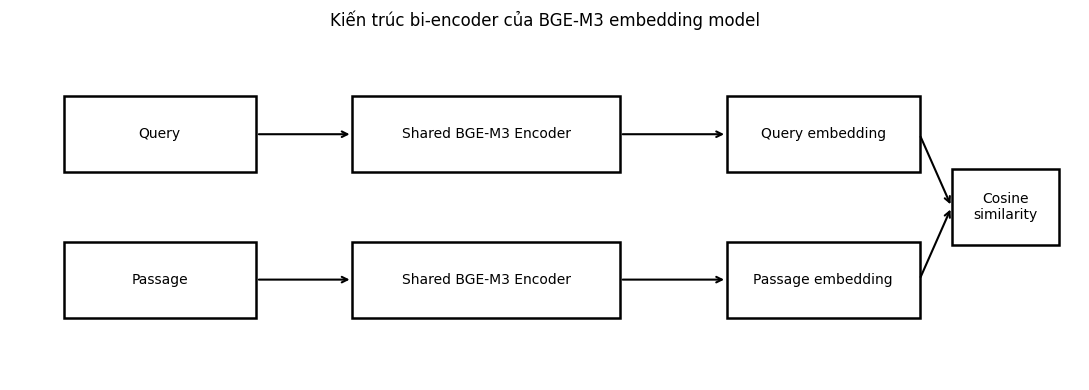

In [ ]:
def draw_embedding_architecture_diagram():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    boxes = [
        (0.05, 0.60, 0.18, 0.22, "Query"),
        (0.05, 0.18, 0.18, 0.22, "Passage"),
        (0.32, 0.60, 0.25, 0.22, "Shared BGE-M3 Encoder"),
        (0.32, 0.18, 0.25, 0.22, "Shared BGE-M3 Encoder"),
        (0.67, 0.60, 0.18, 0.22, "Query embedding"),
        (0.67, 0.18, 0.18, 0.22, "Passage embedding"),
        (0.88, 0.39, 0.10, 0.22, "Cosine\nsimilarity"),
    ]

    for x, y, w, h, text in boxes:
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=1.8))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

    arrows = [
        ((0.23, 0.71), (0.32, 0.71)),
        ((0.23, 0.29), (0.32, 0.29)),
        ((0.57, 0.71), (0.67, 0.71)),
        ((0.57, 0.29), (0.67, 0.29)),
        ((0.85, 0.71), (0.88, 0.50)),
        ((0.85, 0.29), (0.88, 0.50)),
    ]
    for start, end in arrows:
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.5))

    plt.title("Kiến trúc bi-encoder của BGE-M3 embedding model")
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACT_DIR, "figure_1_embedding_architecture.png"), dpi=200, bbox_inches="tight")
    plt.show()


draw_embedding_architecture_diagram()

*Hình 1. Sơ đồ kiến trúc bi-encoder của mô hình embedding. Query và passage được mã hóa độc lập bằng encoder dùng chung, sau đó so sánh bằng cosine similarity.*

## 8. Kiểm tra ảnh hưởng của `MAX_SEQ_LENGTH`

Với embedding model, `query` và `passage` được encode riêng. Vì vậy `MAX_SEQ_LENGTH = 512` áp dụng riêng cho từng text. Nếu passage dài hơn giới hạn, phần cuối sẽ bị truncate. Đây là khác biệt quan trọng so với reranker cross-encoder, nơi `query + passage` cùng nằm trong một sequence.

## 9. Cấu hình huấn luyện và siêu tham số

In [ ]:
def build_examples(data: List[Dict[str, str]]) -> List[InputExample]:
    return [InputExample(texts=[item["query"], item["pos"]]) for item in data]


train_examples = build_examples(train_data)

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=BATCH_SIZE,
    collate_fn=model.smart_batching_collate,
    drop_last=True,
)

train_loss_fn = losses.MultipleNegativesRankingLoss(model)

steps_per_epoch = math.ceil(len(train_dataloader) / GRADIENT_ACCUMULATION_STEPS)
total_training_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_training_steps * WARMUP_RATIO)
SYNC_EVAL_STEPS = max(1, steps_per_epoch // LOG_EVALS_PER_EPOCH)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)

hyperparam_table = pd.DataFrame([
    {"Hyperparameter": "Model", "Value": MODEL_NAME},
    {"Hyperparameter": "Loss", "Value": "MultipleNegativesRankingLoss"},
    {"Hyperparameter": "Optimizer", "Value": "AdamW"},
    {"Hyperparameter": "Learning rate", "Value": LEARNING_RATE},
    {"Hyperparameter": "Weight decay", "Value": WEIGHT_DECAY},
    {"Hyperparameter": "Batch size", "Value": BATCH_SIZE},
    {"Hyperparameter": "Epochs", "Value": EPOCHS},
    {"Hyperparameter": "Warmup ratio", "Value": WARMUP_RATIO},
    {"Hyperparameter": "Warmup steps", "Value": warmup_steps},
    {"Hyperparameter": "Gradient accumulation steps", "Value": GRADIENT_ACCUMULATION_STEPS},
    {"Hyperparameter": "Max sequence length", "Value": MAX_SEQ_LENGTH},
    {"Hyperparameter": "AMP/fp16", "Value": USE_AMP},
    {"Hyperparameter": "Training negative strategy", "Value": "In-batch negatives"},
    {"Hyperparameter": "Validation/Test negative strategy", "Value": "TF-IDF hard negatives"},
    {"Hyperparameter": "Eval negatives per query", "Value": EVAL_NEGATIVES_PER_QUERY},
    {"Hyperparameter": "Eval TF-IDF top-k pool", "Value": EVAL_TFIDF_TOP_K_POOL},
    {"Hyperparameter": "LOG_EVALS_PER_EPOCH", "Value": LOG_EVALS_PER_EPOCH},
    {"Hyperparameter": "SYNC_EVAL_STEPS", "Value": SYNC_EVAL_STEPS},
    {"Hyperparameter": "Early stopping patience", "Value": EARLY_STOPPING_PATIENCE},
    {"Hyperparameter": "Early stopping threshold", "Value": EARLY_STOPPING_THRESHOLD},
    {"Hyperparameter": "Tuning method", "Value": "Thử nghiệm thủ công theo giới hạn GPU"},
])

print("Bảng 6. Cấu hình huấn luyện và siêu tham số")
print("Update steps/epoch:", steps_per_epoch)
print("Log/Eval mỗi", SYNC_EVAL_STEPS, "optimizer steps")
print("Ước tính số điểm validation:", math.ceil(EPOCHS * steps_per_epoch / SYNC_EVAL_STEPS))
display(hyperparam_table)
hyperparam_table.to_csv(os.path.join(ARTIFACT_DIR, "table_6_hyperparams.csv"), index=False, encoding="utf-8-sig")

Bảng 6. Cấu hình huấn luyện và siêu tham số
Update steps/epoch: 827
Log/Eval mỗi 206 optimizer steps
Ước tính số điểm validation: 9


,Hyperparameter,Value
0,Model,BAAI/bge-m3
1,Loss,MultipleNegativesRankingLoss
2,Optimizer,AdamW
3,Learning rate,0.00002
4,Weight decay,0.01
5,Batch size,8
6,Epochs,2
7,Warmup ratio,0.1
8,Warmup steps,165
9,Gradient accumulation steps,4


## 10. Hàm đánh giá retrieval và classification view

Validation/test dùng cùng một protocol: mỗi query có 1 positive passage và `EVAL_NEGATIVES_PER_QUERY` TF-IDF hard negatives. Mô hình encode query/candidates riêng, tính cosine similarity, sau đó xếp hạng candidates.

In [ ]:
def build_embedding_ranking_candidates(
    eval_data: List[Dict[str, str]],
    idx: int,
    num_negatives: int,
    rng: random.Random,
    precomputed_negatives: Optional[List[List[str]]] = None,
) -> Tuple[str, List[str], int]:
    item = eval_data[idx]
    query = item["query"]
    positive = item["pos"]
    negatives = []

    if precomputed_negatives is not None:
        for candidate in precomputed_negatives[idx]:
            if candidate != positive and candidate not in negatives:
                negatives.append(candidate)
            if len(negatives) == num_negatives:
                break

    attempts = 0
    while len(negatives) < num_negatives and attempts < 1000:
        j = rng.randrange(len(eval_data))
        candidate = eval_data[j]["pos"]
        if j != idx and candidate != positive and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    if len(negatives) < num_negatives:
        for j, other in enumerate(eval_data):
            candidate = other["pos"]
            if j != idx and candidate != positive and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

    candidates = [positive] + negatives
    order = list(range(len(candidates)))
    rng.shuffle(order)
    shuffled_candidates = [candidates[i] for i in order]
    positive_new_idx = order.index(0)
    return query, shuffled_candidates, positive_new_idx


def compute_ranking_metrics(ranks: List[int], candidates_per_query: int) -> Dict[str, float]:
    ranks = np.array(ranks)
    metrics = {
        "MRR@10": float(np.mean([1.0 / r if r <= 10 else 0.0 for r in ranks])),
        "NDCG@10": float(np.mean([1.0 / math.log2(r + 1) if r <= 10 else 0.0 for r in ranks])),
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@3": float(np.mean(ranks <= 3)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "MeanRank": float(np.mean(ranks)),
        "MedianRank": float(np.median(ranks)),
        "NumQueries": int(len(ranks)),
        "CandidatesPerQuery": int(candidates_per_query),
    }
    return metrics


def top1_classification_metrics_from_ranks(ranks: List[int], candidates_per_query: int) -> Tuple[Dict[str, float], np.ndarray]:
    ranks = np.array(ranks)
    n = len(ranks)
    tp = int(np.sum(ranks == 1))
    fn = int(n - tp)
    fp = int(n - tp)
    tn = int(n * (candidates_per_query - 1) - fp)

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    metrics = {
        "Top1_Accuracy": float(accuracy),
        "Top1_Precision": float(precision),
        "Top1_Recall": float(recall),
        "Top1_F1": float(f1),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }
    cm = np.array([[tn, fp], [fn, tp]])
    return metrics, cm

def compute_embedding_group_loss(
    model: SentenceTransformer,
    eval_data: List[Dict[str, str]],
    precomputed_negatives: List[List[str]],
    num_negatives: int = 31,
    seed: int = 42,
    encode_batch_size: int = 32,
    query_batch_size: int = 64,
) -> float:
    """Validation loss trên group 1 positive + N hard negatives bằng cross-entropy trên cosine scores."""
    rng = random.Random(seed)
    model.eval()
    values = []

    with torch.no_grad():
        for start in range(0, len(eval_data), query_batch_size):
            end = min(start + query_batch_size, len(eval_data))
            batch_queries, batch_candidates, batch_positive_indices = [], [], []

            for idx in range(start, end):
                query, candidates, positive_idx = build_embedding_ranking_candidates(
                    eval_data,
                    idx,
                    num_negatives,
                    rng,
                    precomputed_negatives=precomputed_negatives,
                )
                batch_queries.append(query)
                batch_candidates.append(candidates)
                batch_positive_indices.append(positive_idx)

            flat_passages = [passage for candidates in batch_candidates for passage in candidates]
            offsets = np.cumsum([0] + [len(c) for c in batch_candidates])

            query_emb = model.encode(
                batch_queries,
                batch_size=encode_batch_size,
                convert_to_tensor=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            ).to(DEVICE)
            passage_emb = model.encode(
                flat_passages,
                batch_size=encode_batch_size,
                convert_to_tensor=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            ).to(DEVICE)

            scores = torch.stack([
                query_emb[i] @ passage_emb[offsets[i]:offsets[i + 1]].T
                for i in range(len(batch_queries))
            ])
            labels = torch.tensor(batch_positive_indices, dtype=torch.long, device=scores.device)
            loss_value = torch.nn.functional.cross_entropy(scores, labels)
            values.append(float(loss_value.detach().cpu()))

            del query_emb, passage_emb
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return float(np.mean(values)) if values else np.nan


def print_metrics(metrics: Dict[str, float]):
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

def evaluate_embedding_ranking(
    model: SentenceTransformer,
    eval_data: List[Dict[str, str]],
    num_negatives: int = 31,
    seed: int = 42,
    encode_batch_size: int = 128,
    query_batch_size: int = 64,
    return_details: bool = False,
    precomputed_negatives: Optional[List[List[str]]] = None,
    desc: str = "Evaluating embedding ranking",
    compute_loss: bool = True,
):
    rng = random.Random(seed)
    ranks = []
    details = []
    loss_values = []

    if precomputed_negatives is not None:
        assert len(precomputed_negatives) == len(eval_data), "precomputed_negatives phải cùng độ dài với eval_data."

    model.eval()

    with torch.inference_mode():
        progress = tqdm(
            range(0, len(eval_data), query_batch_size),
            desc=desc,
            leave=True
        )

        for start in progress:
            end = min(start + query_batch_size, len(eval_data))

            batch_queries = []
            batch_candidates = []
            batch_positive_indices = []
            batch_item_indices = []

            for idx in range(start, end):
                query, candidates, positive_idx = build_embedding_ranking_candidates(
                    eval_data,
                    idx,
                    num_negatives,
                    rng,
                    precomputed_negatives=precomputed_negatives,
                )

                batch_queries.append(query)
                batch_candidates.append(candidates)
                batch_positive_indices.append(positive_idx)
                batch_item_indices.append(idx)

            flat_passages = [
                passage
                for candidates in batch_candidates
                for passage in candidates
            ]

            offsets = np.cumsum([0] + [len(c) for c in batch_candidates])

            query_emb = model.encode(
                batch_queries,
                batch_size=encode_batch_size,
                convert_to_tensor=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            ).to(DEVICE)

            passage_emb = model.encode(
                flat_passages,
                batch_size=encode_batch_size,
                convert_to_tensor=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            ).to(DEVICE)

            score_rows = []

            for local_i in range(len(batch_queries)):
                cand_start = offsets[local_i]
                cand_end = offsets[local_i + 1]

                cand_emb = passage_emb[cand_start:cand_end]
                scores = (query_emb[local_i:local_i + 1] @ cand_emb.T).squeeze(0)

                score_rows.append(scores)

            scores_tensor = torch.stack(score_rows)

            labels = torch.tensor(
                batch_positive_indices,
                dtype=torch.long,
                device=scores_tensor.device
            )

            if compute_loss:
                loss_value = torch.nn.functional.cross_entropy(scores_tensor, labels)
                loss_values.append(float(loss_value.detach().cpu()))

            sorted_indices = torch.argsort(
                scores_tensor,
                dim=1,
                descending=True
            ).detach().cpu().numpy()

            scores_np = scores_tensor.detach().cpu().numpy()

            for local_i, idx in enumerate(batch_item_indices):
                positive_idx = batch_positive_indices[local_i]
                sorted_idx = sorted_indices[local_i]

                rank = int(np.where(sorted_idx == positive_idx)[0][0]) + 1
                ranks.append(rank)

                if return_details:
                    top_idx = int(sorted_idx[0])
                    candidates = batch_candidates[local_i]

                    details.append({
                        "query": batch_queries[local_i],
                        "positive_passage": candidates[positive_idx],
                        "predicted_top_passage": candidates[top_idx],
                        "positive_rank": rank,
                        "positive_score": float(scores_np[local_i, positive_idx]),
                        "top1_score": float(scores_np[local_i, top_idx]),
                        "is_top1_correct": bool(rank == 1),
                        "source": eval_data[idx].get("source", ""),
                    })

            current_mrr = np.mean([
                1.0 / r if r <= 10 else 0.0
                for r in ranks
            ])

            current_r1 = np.mean(np.array(ranks) <= 1)

            postfix = {
                "MRR@10": f"{current_mrr:.4f}",
                "R@1": f"{current_r1:.4f}",
            }

            if compute_loss and loss_values:
                postfix["loss"] = f"{np.mean(loss_values):.4f}"

            progress.set_postfix(postfix)

            del query_emb, passage_emb, scores_tensor, labels, score_rows
            del sorted_indices, scores_np

            if compute_loss:
                del loss_value

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    candidates_per_query = num_negatives + 1

    metrics = compute_ranking_metrics(
        ranks,
        candidates_per_query=candidates_per_query
    )

    top1_metrics, cm = top1_classification_metrics_from_ranks(
        ranks,
        candidates_per_query=candidates_per_query
    )

    metrics.update(top1_metrics)

    if compute_loss:
        metrics["Eval_Loss"] = float(np.mean(loss_values)) if loss_values else np.nan

    details_df = pd.DataFrame(details)

    return metrics, ranks, cm, details_df

## 11. Đánh giá baseline trước fine-tune

Baseline là mô hình `BAAI/bge-m3` pretrained ban đầu, chưa cập nhật trọng số trên dữ liệu pháp luật. Baseline và mô hình fine-tuned được đánh giá trên cùng test set và cùng TF-IDF hard negatives để đảm bảo so sánh công bằng.

In [ ]:
if RUN_BASELINE_EVAL:
    print("=" * 60)
    print("ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET")
    print("=" * 60)
    print("Test negative sampling: TF-IDF hard negatives")
    print("Sử dụng model hiện tại trước fine-tune làm baseline pretrained.")

    baseline_metrics, baseline_ranks, baseline_cm, _ = evaluate_embedding_ranking(
        model,
        eval_data=eval_test_data,
        num_negatives=EVAL_NEGATIVES_PER_QUERY,
        seed=SEED,
        encode_batch_size=EVAL_ENCODE_BATCH_SIZE,
        query_batch_size=EVAL_QUERY_BATCH_SIZE,
        return_details=False,
        precomputed_negatives=test_ranking_negatives,
        desc="Evaluating pretrained embedding baseline on test",
        compute_loss=False,
    )

    print_metrics(baseline_metrics)

    os.makedirs("./eval_embedding_baseline", exist_ok=True)

    with open("./eval_embedding_baseline/metrics.json", "w", encoding="utf-8") as f:
        json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)

    # Không cần baseline_details cho báo cáo chính.
    baseline_details = pd.DataFrame()

else:
    baseline_metrics, baseline_ranks, baseline_cm, baseline_details = {}, [], None, pd.DataFrame()

ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET
Test negative sampling: TF-IDF hard negatives
Sử dụng model hiện tại trước fine-tune làm baseline pretrained.


Evaluating pretrained embedding baseline on test:   0%|          | 0/178 [00:00<?, ?it/s]

MRR@10: 0.9541
NDCG@10: 0.9629
Recall@1: 0.9317
Recall@3: 0.9728
Recall@5: 0.9822
Recall@10: 0.9896
MeanRank: 1.3305
MedianRank: 1.0000
NumQueries: 5667
CandidatesPerQuery: 32
Top1_Accuracy: 0.9957
Top1_Precision: 0.9317
Top1_Recall: 0.9317
Top1_F1: 0.9317
TP: 5280
FP: 387
FN: 387
TN: 175290


In [ ]:
# ============================================================
# CLEAN MEMORY SAU KHI ĐÁNH GIÁ BASELINE
# ============================================================

import gc
import os
import pickle
import torch

print("=" * 60)
print("DỌN BỘ NHỚ SAU BASELINE EVALUATION")
print("=" * 60)

CACHE_DIR = "./embedding_eval_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

TEST_NEGATIVES_CACHE = os.path.join(CACHE_DIR, "test_ranking_negatives.pkl")

if "test_ranking_negatives" in globals():
    with open(TEST_NEGATIVES_CACHE, "wb") as f:
        pickle.dump(test_ranking_negatives, f)
    print(f"Đã lưu test_ranking_negatives vào: {TEST_NEGATIVES_CACHE}")

variables_to_delete = [
    "baseline_ranks",
    "baseline_cm",
    "baseline_details",
    "test_ranking_negatives",
    "validation_examples",
    "validation_loss_dataloader",
]

for var_name in variables_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Đã xóa biến: {var_name}")

# Đảm bảo model trở lại train mode
model.train()

# Dọn CPU RAM
gc.collect()

# Dọn GPU cache
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )
    print(
        "GPU memory reserved :",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )

try:
    import psutil
    process = psutil.Process(os.getpid())
    print(
        "CPU RAM used:",
        round(process.memory_info().rss / 1024**3, 2),
        "GB"
    )
except Exception as e:
    print("Không đọc được CPU RAM:", e)

print("Hoàn tất dọn bộ nhớ. Có thể bắt đầu fine-tuning.")

DỌN BỘ NHỚ SAU BASELINE EVALUATION
Đã lưu test_ranking_negatives vào: ./embedding_eval_cache/test_ranking_negatives.pkl
Đã xóa biến: baseline_ranks
Đã xóa biến: baseline_cm
Đã xóa biến: baseline_details
Đã xóa biến: test_ranking_negatives
GPU memory allocated: 2.12 GB
GPU memory reserved : 2.13 GB
CPU RAM used: 2.15 GB
Hoàn tất dọn bộ nhớ. Có thể bắt đầu fine-tuning.


## 12. Fine-tuning với synchronized logging và early stopping

In [ ]:
from IPython.display import display

history_rows = []
best_val_mrr = -1.0
no_improve_count = 0
global_step = 0
stop_training = False
last_eval_step = -1
train_losses_since_log = []

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# Bảng live log giống HuggingFace Trainer / file rerank
DISPLAY_COLUMNS = {
    "step": "Step",
    "train_loss": "Training Loss",
    "eval_loss": "Validation Loss",
    "eval_top1_accuracy": "Top1 Accuracy",
    "eval_mrr": "Mrr",
}

live_log_display = display(
    pd.DataFrame(columns=list(DISPLAY_COLUMNS.values())),
    display_id=True
)

print("=" * 60)
print("BẮT ĐẦU FINE-TUNING EMBEDDING MODEL")
print("=" * 60)
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE}, threshold={EARLY_STOPPING_THRESHOLD}")
print("Validation negatives:", "TF-IDF hard negatives")

for epoch in range(1, EPOCHS + 1):
    if stop_training:
        break

    model.train()
    optimizer.zero_grad(set_to_none=True)
    progress = tqdm(train_dataloader, desc=f"Epoch {epoch}/{EPOCHS}")

    for step, batch in enumerate(progress, start=1):
        sentence_features, labels = batch
        sentence_features = [batch_to_device(feature, DEVICE) for feature in sentence_features]
        labels = labels.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            loss_value = train_loss_fn(sentence_features, labels)
            loss_to_backward = loss_value / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss_to_backward).backward()
        train_losses_since_log.append(float(loss_value.detach().cpu()))

        should_step = (step % GRADIENT_ACCUMULATION_STEPS == 0) or (step == len(train_dataloader))

        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

            should_eval = (global_step % SYNC_EVAL_STEPS == 0) or (step == len(train_dataloader))

            if should_eval and global_step != last_eval_step:
                last_eval_step = global_step
                epoch_progress = (epoch - 1) + step / max(len(train_dataloader), 1)

                train_loss_logged = (
                    float(np.mean(train_losses_since_log))
                    if train_losses_since_log
                    else np.nan
                )
                train_losses_since_log = []

                tqdm.write(f"Bắt đầu validation @ step {global_step}...")

                validation_metrics, _, _, _ = evaluate_embedding_ranking(
                    model=model,
                    eval_data=eval_val_data,
                    num_negatives=EVAL_NEGATIVES_PER_QUERY,
                    seed=SEED,
                    encode_batch_size=EVAL_ENCODE_BATCH_SIZE,
                    query_batch_size=EVAL_QUERY_BATCH_SIZE,
                    return_details=False,
                    precomputed_negatives=val_ranking_negatives,
                    desc=f"Validation @ step {global_step}",
                    compute_loss=True,
                )

                validation_loss = validation_metrics["Eval_Loss"]

                row = {
                    "step": global_step,
                    "epoch": epoch_progress,
                    "train_loss": train_loss_logged,
                    "eval_loss": validation_loss,
                    "eval_mrr": validation_metrics["MRR@10"],
                    "eval_top1_accuracy": validation_metrics["Top1_Accuracy"],
                    "eval_recall_at_1": validation_metrics["Recall@1"],
                    "eval_recall_at_5": validation_metrics["Recall@5"],
                    "eval_ndcg_at_10": validation_metrics["NDCG@10"],
                    "learning_rate": scheduler.get_last_lr()[0],
                }

                history_rows.append(row)

                log_display_df = pd.DataFrame(history_rows)

                log_display_df = log_display_df[list(DISPLAY_COLUMNS.keys())].rename(
                    columns=DISPLAY_COLUMNS
                )

                for col in ["Training Loss", "Validation Loss", "Top1 Accuracy", "Mrr"]:
                    log_display_df[col] = log_display_df[col].astype(float).round(6)

                live_log_display.update(log_display_df)

                tqdm.write(
                    f"Step {global_step} | Epoch {epoch_progress:.2f} | "
                    f"train_loss={train_loss_logged:.4f} | "
                    f"val_loss={validation_loss:.4f} | "
                    f"val_MRR@10={validation_metrics['MRR@10']:.4f} | "
                    f"val_R@1={validation_metrics['Recall@1']:.4f}"
                )

                current_val_mrr = validation_metrics["MRR@10"]

                if current_val_mrr > best_val_mrr + EARLY_STOPPING_THRESHOLD:
                    best_val_mrr = current_val_mrr
                    no_improve_count = 0

                    import shutil

                    if os.path.exists(BEST_MODEL_PATH):
                        shutil.rmtree(BEST_MODEL_PATH)
                        tqdm.write(f"Đã xóa checkpoint cũ tại: {BEST_MODEL_PATH}")

                    os.makedirs(BEST_MODEL_PATH, exist_ok=True)
                    model.save(BEST_MODEL_PATH)

                    tqdm.write(
                        f"Đã lưu best checkpoint mới tại {BEST_MODEL_PATH} "
                        f"với eval_mrr={best_val_mrr:.4f}"
                    )
                else:
                    no_improve_count += 1

                    tqdm.write(
                        f"Không cải thiện đủ ngưỡng. "
                        f"Early stopping counter: {no_improve_count}/{EARLY_STOPPING_PATIENCE}"
                    )

                    if no_improve_count >= EARLY_STOPPING_PATIENCE:
                        tqdm.write("Dừng sớm do validation MRR@10 không cải thiện.")
                        stop_training = True
                        break

                if not stop_training:
                    import gc

                    gc.collect()

                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                        torch.cuda.ipc_collect()

                        tqdm.write(
                            "GPU sau validation | allocated="
                            f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB | "
                            "reserved="
                            f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
                        )

                    model.train()

        progress.set_postfix({
            "loss": float(np.mean(train_losses_since_log[-20:]))
            if train_losses_since_log
            else np.nan
        })

history = pd.DataFrame(history_rows)

history.to_csv(
    "./training_log_history_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

history.to_csv(
    os.path.join(ARTIFACT_DIR, "table_7_training_history_synced.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Bảng 7. Log train/validation đã đồng bộ theo step")
display(history)

/tmp/ipykernel_37819/694366928.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


,Step,Training Loss,Validation Loss,Top1 Accuracy,Mrr
0,206,0.009742,2.972756,0.998219,0.982546
1,412,0.002916,2.960918,0.998250,0.983833
2,618,0.002523,2.936999,0.998156,0.983101
3,824,0.004679,2.928086,0.998312,0.984324
4,827,0.000128,2.927270,0.998344,0.984741
5,1030,0.001804,2.914353,0.998531,0.986534
6,1236,0.001974,2.906086,0.998438,0.985596
7,1442,0.001423,2.907190,0.998781,0.988930
8,1648,0.001829,2.903312,0.998875,0.989996
9,1654,0.000889,2.903308,0.998875,0.989996


BẮT ĐẦU FINE-TUNING EMBEDDING MODEL
Early stopping: patience=3, threshold=0.0005
Validation negatives: TF-IDF hard negatives


Epoch 1/2:   0%|          | 0/3305 [00:00<?, ?it/s]

/tmp/ipykernel_37819/694366928.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

/tmp/ipykernel_37819/694366928.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Bắt đầu validation @ step 1654...


Validation @ step 1654:   0%|          | 0/63 [00:00<?, ?it/s]

Step 1654 | Epoch 2.00 | train_loss=0.0009 | val_loss=2.9033 | val_MRR@10=0.9900 | val_R@1=0.9820
Không cải thiện đủ ngưỡng. Early stopping counter: 1/3
GPU sau validation | allocated=6.37 GB | reserved=6.67 GB
Bảng 7. Log train/validation đã đồng bộ theo step


,step,epoch,train_loss,eval_loss,eval_mrr,eval_top1_accuracy,eval_recall_at_1,eval_recall_at_5,eval_ndcg_at_10,learning_rate
0,206,0.249319,0.009742,2.972756,0.982546,0.998219,0.9715,0.9955,0.986654,1.944929e-05
1,412,0.498638,0.002916,2.960918,0.983833,0.998250,0.9720,0.9975,0.987815,1.668234e-05
2,618,0.747958,0.002523,2.936999,0.983101,0.998156,0.9705,0.9980,0.987276,1.391538e-05
3,824,0.997277,0.004679,2.928086,0.984324,0.998313,0.9730,0.9975,0.988274,1.114842e-05
4,827,1.000000,0.000128,2.927270,0.984741,0.998344,0.9735,0.9975,0.988589,1.110813e-05
5,1030,1.245688,0.001804,2.914353,0.986534,0.998531,0.9765,0.9985,0.989938,8.381464e-06
6,1236,1.495008,0.001974,2.906086,0.985596,0.998437,0.9750,0.9985,0.989119,5.614506e-06
7,1442,1.744327,0.001423,2.907190,0.988930,0.998781,0.9805,0.9990,0.991734,2.847549e-06
8,1648,1.993646,0.001829,2.903312,0.989996,0.998875,0.9820,0.9990,0.992540,8.059100e-08
9,1654,2.000000,0.000889,2.903308,0.989996,0.998875,0.9820,0.9990,0.992540,0.000000e+00


### 12.1. Learning curves: Loss và metric trên Train/Validation đồng bộ

Bảng 8. Log train/validation đã đồng bộ theo step


,step,epoch,train_loss,eval_loss,eval_mrr,eval_top1_accuracy,eval_recall_at_1,eval_recall_at_5,eval_ndcg_at_10,learning_rate
0,206,0.249319,0.009742,2.972756,0.982546,0.998219,0.9715,0.9955,0.986654,1.944929e-05
1,412,0.498638,0.002916,2.960918,0.983833,0.998250,0.9720,0.9975,0.987815,1.668234e-05
2,618,0.747958,0.002523,2.936999,0.983101,0.998156,0.9705,0.9980,0.987276,1.391538e-05
3,824,0.997277,0.004679,2.928086,0.984324,0.998313,0.9730,0.9975,0.988274,1.114842e-05
4,827,1.000000,0.000128,2.927270,0.984741,0.998344,0.9735,0.9975,0.988589,1.110813e-05
5,1030,1.245688,0.001804,2.914353,0.986534,0.998531,0.9765,0.9985,0.989938,8.381464e-06
6,1236,1.495008,0.001974,2.906086,0.985596,0.998437,0.9750,0.9985,0.989119,5.614506e-06
7,1442,1.744327,0.001423,2.907190,0.988930,0.998781,0.9805,0.9990,0.991734,2.847549e-06
8,1648,1.993646,0.001829,2.903312,0.989996,0.998875,0.9820,0.9990,0.992540,8.059100e-08
9,1654,2.000000,0.000889,2.903308,0.989996,0.998875,0.9820,0.9990,0.992540,0.000000e+00


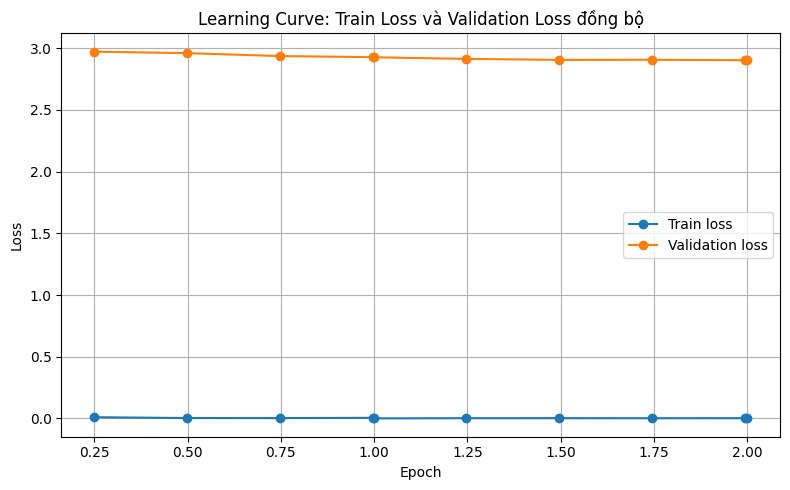

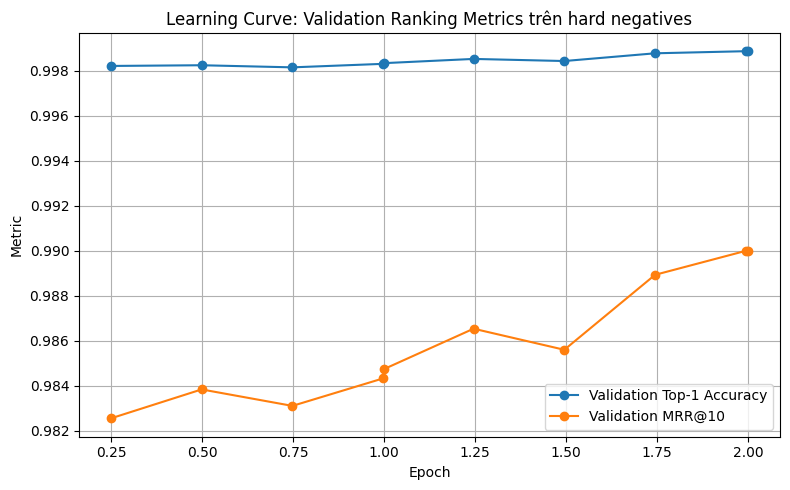

In [ ]:
synced_history = history.copy()
synced_history.to_csv("./training_log_history_synced.csv", index=False, encoding="utf-8-sig")

print("Bảng 8. Log train/validation đã đồng bộ theo step")
display(synced_history)

plt.figure(figsize=(8, 5))
if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]
    plt.plot(x, synced_history["train_loss"], marker="o", label="Train loss")
    plt.plot(x, synced_history["eval_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve: Train Loss và Validation Loss đồng bộ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure_2_loss_curve_synced.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]
    plt.plot(x, synced_history["eval_top1_accuracy"], marker="o", label="Validation Top-1 Accuracy")
    plt.plot(x, synced_history["eval_mrr"], marker="o", label="Validation MRR@10")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Learning Curve: Validation Ranking Metrics trên hard negatives")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure_3_validation_metrics_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

*Hình 2. Learning curve của train loss và validation loss theo các mốc step/epoch đã đồng bộ. Biểu đồ dùng để nhận xét mô hình có hội tụ hay không và có dấu hiệu overfitting hay không.*

*Hình 3. Learning curve của validation top-1 accuracy/MRR@10 trên TF-IDF hard negatives theo các mốc step/epoch. Metric tăng ổn định thường cho thấy chất lượng ranking cải thiện.*

## 13. Đánh giá trên tập Test sau fine-tune

Tập test chỉ được sử dụng sau khi đã chọn checkpoint tốt nhất theo validation. Đây là kết quả dùng cho phần báo cáo mô hình cá nhân.

In [ ]:
# ============================================================
# DỌN TRAINING OBJECTS TRƯỚC KHI LOAD BEST CHECKPOINT
# ============================================================

import gc
import torch

print("=" * 60)
print("DỌN BỘ NHỚ TRƯỚC FINAL TEST")
print("=" * 60)

# Xóa các object chỉ dùng cho training để tránh giữ model cũ trong GPU/RAM
training_objects_to_delete = [
    "train_loss_fn",
    "optimizer",
    "scheduler",
    "train_dataloader",
    "train_examples",
    "validation_examples",
    "validation_loss_dataloader",
]

for var_name in training_objects_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Đã xóa biến training: {var_name}")

# Nếu sẽ load best checkpoint, xóa model hiện tại trước để tránh giữ 2 model trên GPU
load_best_checkpoint = os.path.exists(BEST_MODEL_PATH)

if load_best_checkpoint:
    if "model" in globals():
        del model
        print("Đã xóa model hiện tại khỏi memory trước khi load best checkpoint.")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("GPU memory allocated:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")
    print("GPU memory reserved :", round(torch.cuda.memory_reserved() / 1024**3, 2), "GB")

if load_best_checkpoint:
    model = SentenceTransformer(BEST_MODEL_PATH, device=DEVICE)
    model.max_seq_length = MAX_SEQ_LENGTH
    print("Đã load best checkpoint:", BEST_MODEL_PATH)
else:
    print("Không tìm thấy best checkpoint, dùng model hiện tại trong bộ nhớ.")

DỌN BỘ NHỚ TRƯỚC FINAL TEST
Đã xóa biến training: train_loss_fn
Đã xóa biến training: optimizer
Đã xóa biến training: scheduler
Đã xóa biến training: train_dataloader
Đã xóa biến training: train_examples
Đã xóa model hiện tại khỏi memory trước khi load best checkpoint.
GPU memory allocated: 2.14 GB
GPU memory reserved : 2.21 GB
Đã load best checkpoint: ./vietlaw-bge-m3-finetuned/best


In [ ]:
# ============================================================
# LOAD LẠI TEST HARD NEGATIVES VÀ ĐÁNH GIÁ FINAL TEST
# ============================================================

import os
import pickle
import gc
import torch

print("=" * 60)
print("CHUẨN BỊ TEST HARD NEGATIVES")
print("=" * 60)

CACHE_DIR = "./embedding_eval_cache"
TEST_NEGATIVES_CACHE = os.path.join(CACHE_DIR, "test_ranking_negatives.pkl")

if "test_ranking_negatives" not in globals():
    if os.path.exists(TEST_NEGATIVES_CACHE):
        with open(TEST_NEGATIVES_CACHE, "rb") as f:
            test_ranking_negatives = pickle.load(f)
        print(f"Đã load lại test_ranking_negatives từ: {TEST_NEGATIVES_CACHE}")
    else:
        print("Không tìm thấy cache test_ranking_negatives. Rebuild lại bằng TF-IDF...")
        test_ranking_negatives = build_tfidf_negatives(
            eval_test_data,
            num_negatives=EVAL_NEGATIVES_PER_QUERY,
            top_k_pool=EVAL_TFIDF_TOP_K_POOL,
            seed=SEED + 29,
            desc="Rebuild test ranking TF-IDF hard negatives",
        )
else:
    print("test_ranking_negatives đã có sẵn trong RAM.")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("=" * 60)
print("ĐÁNH GIÁ MODEL SAU FINE-TUNE TRÊN TEST SET")
print("=" * 60)
print("Test negative sampling: TF-IDF hard negatives")

finetuned_metrics, finetuned_ranks, finetuned_cm, finetuned_details = evaluate_embedding_ranking(
    model,
    eval_data=eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    seed=SEED,
    encode_batch_size=EVAL_ENCODE_BATCH_SIZE,
    query_batch_size=EVAL_QUERY_BATCH_SIZE,
    return_details=True,
    precomputed_negatives=test_ranking_negatives,
    desc="Evaluating fine-tuned embedding on test",
    compute_loss=False,
)

print_metrics(finetuned_metrics)

eval_dir = "./eval_embedding_finetuned"
os.makedirs(eval_dir, exist_ok=True)

with open(os.path.join(eval_dir, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(finetuned_metrics, f, ensure_ascii=False, indent=2)

finetuned_details.to_csv(
    os.path.join(eval_dir, "error_details.csv"),
    index=False,
    encoding="utf-8-sig"
)

### 13.1. Bảng metric định lượng trên Test và so sánh với baseline

In [18]:
# ---------- Paths ----------
if "ARTIFACT_DIR" not in globals():
    ARTIFACT_DIR = "./report_artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

BASELINE_METRICS_PATH = "./eval_embedding_baseline/metrics.json"
FINETUNED_METRICS_PATH = "./eval_embedding_finetuned/metrics.json"
FINETUNED_DETAILS_PATH = "./eval_embedding_finetuned/error_details.csv"

HISTORY_CANDIDATES = [
    "./training_log_history_raw.csv",
    os.path.join(ARTIFACT_DIR, "table_7_training_history_synced.csv"),
]


# ---------- Helper functions ----------
def load_json_if_exists(path, default=None, name="json"):
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        print(f"Đã load {name} từ: {path}")
        return data

    print(f"Không tìm thấy {name}: {path}")
    return default


def load_csv_if_exists(path, default=None, name="csv"):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Đã load {name} từ: {path}")
        return df

    print(f"Không tìm thấy {name}: {path}")
    return default if default is not None else pd.DataFrame()


def load_first_existing_csv(paths, name="csv"):
    for path in paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print(f"Đã load {name} từ: {path}")
            return df

    print(f"Không tìm thấy {name} trong các path đã kiểm tra.")
    return pd.DataFrame()


# ---------- 1. Load metrics ----------
baseline_metrics = load_json_if_exists(
    BASELINE_METRICS_PATH,
    default={},
    name="baseline_metrics",
)

finetuned_metrics = load_json_if_exists(
    FINETUNED_METRICS_PATH,
    default={},
    name="finetuned_metrics",
)

if not finetuned_metrics:
    print("Cảnh báo: chưa có finetuned_metrics. Cần chạy final test trước khi tạo bảng so sánh.")


# ---------- 2. Load fine-tuned details ----------
finetuned_details = load_csv_if_exists(
    FINETUNED_DETAILS_PATH,
    default=pd.DataFrame(),
    name="finetuned_details",
)


# ---------- 3. Load training history ----------
history = load_first_existing_csv(
    HISTORY_CANDIDATES,
    name="training history",
)

if not history.empty:
    print("Training history tail:")
    display(history.tail())
else:
    print("Không có history. Các nhận xét training có thể bị thiếu.")


# ---------- 4. Khôi phục best_val_mrr từ history ----------
best_val_mrr = None
best_val_step = None

if not history.empty and "eval_mrr" in history.columns:
    history["eval_mrr"] = history["eval_mrr"].astype(float)

    best_idx = history["eval_mrr"].idxmax()
    best_val_mrr = float(history.loc[best_idx, "eval_mrr"])

    if "step" in history.columns:
        best_val_step = int(history.loc[best_idx, "step"])

    print(f"Khôi phục best_val_mrr = {best_val_mrr:.6f}")

    if best_val_step is not None:
        print(f"Best validation step = {best_val_step}")
else:
    print("Không thể khôi phục best_val_mrr vì history rỗng hoặc thiếu cột eval_mrr.")


# ---------- 5. Khôi phục confusion matrix phụ nếu cần ----------
finetuned_cm = None

if not finetuned_details.empty and "is_top1_correct" in finetuned_details.columns:
    is_correct = finetuned_details["is_top1_correct"].astype(bool)

    tp = int(is_correct.sum())
    fn = int((~is_correct).sum())

    # Đây chỉ là confusion matrix phụ cho top-1 correctness.
    # Không khôi phục được TN/FP đầy đủ nếu không lưu toàn bộ ranks/candidates.
    finetuned_cm = np.array([[tp, fn], [0, 0]])

    print("Đã tạo finetuned_cm tạm từ finetuned_details.")
else:
    print("Không đủ dữ liệu để tạo finetuned_cm.")

Đã load baseline_metrics từ: ./eval_embedding_baseline/metrics.json
Đã load finetuned_metrics từ: ./eval_embedding_finetuned/metrics.json
Đã load finetuned_details từ: ./eval_embedding_finetuned/error_details.csv
Đã load training history từ: ./training_log_history_raw.csv
Training history tail:


,step,epoch,train_loss,eval_loss,eval_mrr,eval_top1_accuracy,eval_recall_at_1,eval_recall_at_5,eval_ndcg_at_10,learning_rate
5,1030,1.245688,0.001804,2.914353,0.986534,0.998531,0.9765,0.9985,0.989938,8.381464e-06
6,1236,1.495008,0.001974,2.906086,0.985596,0.998437,0.9750,0.9985,0.989119,5.614506e-06
7,1442,1.744327,0.001423,2.907190,0.988930,0.998781,0.9805,0.9990,0.991734,2.847549e-06
8,1648,1.993646,0.001829,2.903312,0.989996,0.998875,0.9820,0.9990,0.992540,8.059100e-08
9,1654,2.000000,0.000889,2.903308,0.989996,0.998875,0.9820,0.9990,0.992540,0.000000e+00


Khôi phục best_val_mrr = 0.989996
Best validation step = 1648
Đã tạo finetuned_cm tạm từ finetuned_details.


In [9]:
# ============================================================
# SO SÁNH BASELINE VS FINE-TUNED TRÊN TEST SET
# ============================================================

import os
import json
import pandas as pd

baseline_metrics_path = "./eval_embedding_baseline/metrics.json"
finetuned_metrics_path = "./eval_embedding_finetuned/metrics.json"

# Nếu runtime bị restart hoặc biến bị mất, load lại baseline_metrics từ file
if RUN_BASELINE_EVAL and "baseline_metrics" not in globals():
    if os.path.exists(baseline_metrics_path):
        with open(baseline_metrics_path, "r", encoding="utf-8") as f:
            baseline_metrics = json.load(f)
        print(f"Đã load lại baseline_metrics từ: {baseline_metrics_path}")
    else:
        print("Không tìm thấy baseline metrics. Sẽ chỉ hiển thị kết quả fine-tuned.")
        RUN_BASELINE_EVAL = False

# Nếu finetuned_metrics bị mất, load lại từ file
if "finetuned_metrics" not in globals():
    if os.path.exists(finetuned_metrics_path):
        with open(finetuned_metrics_path, "r", encoding="utf-8") as f:
            finetuned_metrics = json.load(f)
        print(f"Đã load lại finetuned_metrics từ: {finetuned_metrics_path}")
    else:
        raise RuntimeError(
            "Không tìm thấy finetuned_metrics trong RAM hoặc file metrics.json. "
            "Hãy chạy lại cell đánh giá final test trước."
        )

if RUN_BASELINE_EVAL:
    result_summary = pd.DataFrame(
        [baseline_metrics, finetuned_metrics],
        index=[
            "BGE-M3 embedding baseline pretrained",
            "BGE-M3 embedding fine-tuned",
        ],
    )
else:
    result_summary = pd.DataFrame(
        [finetuned_metrics],
        index=["BGE-M3 embedding fine-tuned"],
    )

important_cols = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
    "MeanRank", "MedianRank", "NumQueries", "CandidatesPerQuery", "NegativeSampling",
]

result_summary = result_summary[
    [c for c in important_cols if c in result_summary.columns]
]

print("Bảng 9. So sánh baseline pretrained và BGE-M3 embedding fine-tuned trên tập Test")
display(result_summary)

higher_is_better = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
]

lower_is_better = ["MeanRank", "MedianRank"]

improvement_rows = []

if RUN_BASELINE_EVAL:
    for col in result_summary.columns:
        if col not in higher_is_better and col not in lower_is_better:
            continue

        base = result_summary.loc["BGE-M3 embedding baseline pretrained", col]
        ft = result_summary.loc["BGE-M3 embedding fine-tuned", col]

        if col in higher_is_better:
            delta = ft - base
        else:
            delta = base - ft

        improvement_rows.append({
            "Metric": col,
            "Baseline": base,
            "Fine-tuned": ft,
            "Cải thiện": delta,
        })

improvement_summary = pd.DataFrame(improvement_rows)

if not improvement_summary.empty:
    print("Bảng 9b. Mức cải thiện của mô hình fine-tuned so với baseline")
    display(improvement_summary)

eval_dir = "./eval_embedding_finetuned"
os.makedirs(eval_dir, exist_ok=True)

result_summary.to_csv(
    os.path.join(eval_dir, "test_metrics_comparison_baseline_vs_finetuned.csv"),
    encoding="utf-8-sig"
)

result_summary.to_csv(
    os.path.join(ARTIFACT_DIR, "table_9_test_metrics_comparison_baseline_vs_finetuned.csv"),
    encoding="utf-8-sig"
)

if not improvement_summary.empty:
    improvement_summary.to_csv(
        os.path.join(eval_dir, "test_metric_improvement.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    improvement_summary.to_csv(
        os.path.join(ARTIFACT_DIR, "table_9b_metric_improvement.csv"),
        index=False,
        encoding="utf-8-sig"
    )

Đã load lại baseline_metrics từ: ./eval_embedding_baseline/metrics.json
Đã load lại finetuned_metrics từ: ./eval_embedding_finetuned/metrics.json
Bảng 9. So sánh baseline pretrained và BGE-M3 embedding fine-tuned trên tập Test


,MRR@10,NDCG@10,Recall@1,Recall@3,Recall@5,Recall@10,Top1_Accuracy,Top1_Precision,Top1_Recall,Top1_F1,MeanRank,MedianRank,NumQueries,CandidatesPerQuery
BGE-M3 embedding baseline pretrained,0.954062,0.962854,0.931710,0.972825,0.982178,0.989589,0.995732,0.931710,0.931710,0.931710,1.33051,1.0,5667,32
BGE-M3 embedding fine-tuned,0.980850,0.985560,0.966296,0.995941,0.998588,0.999294,0.997894,0.966296,0.966296,0.966296,1.06229,1.0,5667,32


Bảng 9b. Mức cải thiện của mô hình fine-tuned so với baseline


,Metric,Baseline,Fine-tuned,Cải thiện
0,MRR@10,0.954062,0.980850,0.026788
1,NDCG@10,0.962854,0.985560,0.022706
2,Recall@1,0.931710,0.966296,0.034586
3,Recall@3,0.972825,0.995941,0.023116
4,Recall@5,0.982178,0.998588,0.016411
5,Recall@10,0.989589,0.999294,0.009705
6,Top1_Accuracy,0.995732,0.997894,0.002162
7,Top1_Precision,0.931710,0.966296,0.034586
8,Top1_Recall,0.931710,0.966296,0.034586
9,Top1_F1,0.931710,0.966296,0.034586


### 13.2. Confusion Matrix theo top-1 classification view

Vì retrieval/ranking không phải classification truyền thống, confusion matrix được xây dựng theo góc nhìn top-1:

- Mỗi query có 1 positive passage và `EVAL_NEGATIVES_PER_QUERY` TF-IDF hard negatives.
- Mô hình dự đoán passage có cosine similarity cao nhất là relevant.
- Nếu top-1 là positive passage thì tính là đúng; nếu top-1 là negative passage thì xuất hiện FP/FN.
- Cách này dùng cùng hard negatives với bảng metric ranking chính.

Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test


,Pred non-relevant,Pred relevant
True non-relevant,5476,191
True relevant,0,0


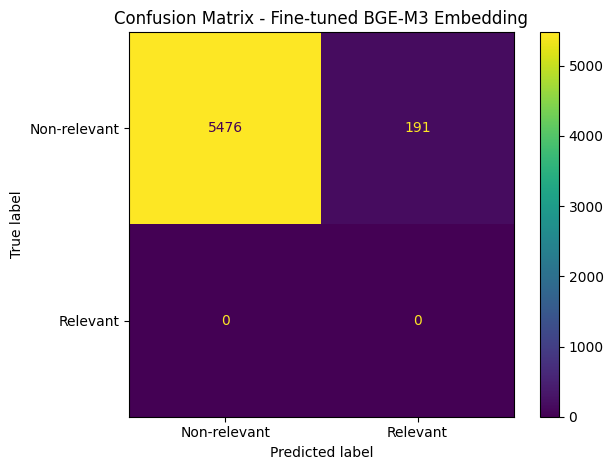

In [12]:
print("Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test")
cm_df = pd.DataFrame(
    finetuned_cm,
    index=["True non-relevant", "True relevant"],
    columns=["Pred non-relevant", "Pred relevant"],
)
display(cm_df)
cm_df.to_csv(os.path.join(ARTIFACT_DIR, "table_10_confusion_matrix.csv"), encoding="utf-8-sig")

disp = ConfusionMatrixDisplay(
    confusion_matrix=finetuned_cm,
    display_labels=["Non-relevant", "Relevant"],
)
disp.plot(values_format="d")
plt.title("Confusion Matrix - Fine-tuned BGE-M3 Embedding")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure_4_confusion_matrix.png"), dpi=200, bbox_inches="tight")
plt.show()

*Hình 4. Confusion Matrix của mô hình fine-tuned trên test set theo top-1 classification view với TF-IDF hard negatives.*

### 13.3. Biểu đồ so sánh baseline và mô hình fine-tuned

<Figure size 1000x500 with 0 Axes>

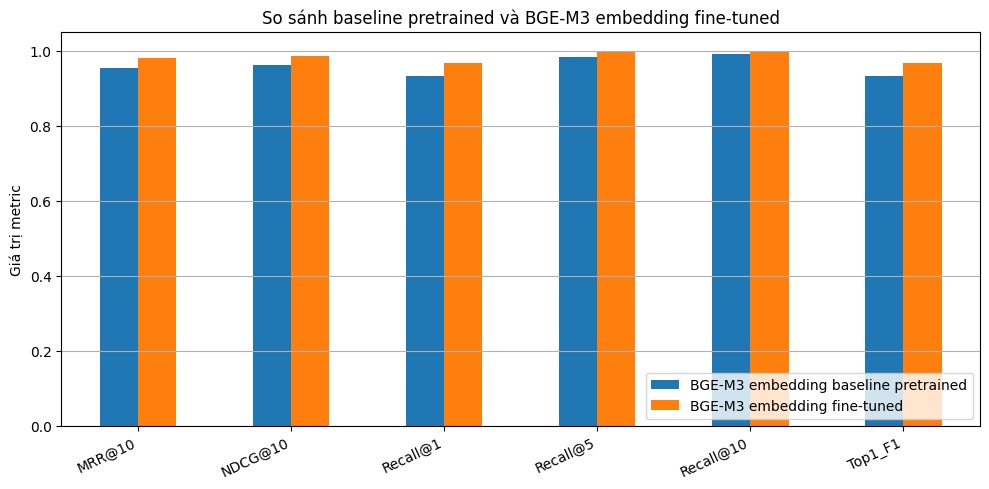

In [13]:
plot_cols = [c for c in ["MRR@10", "NDCG@10", "Recall@1", "Recall@5", "Recall@10", "Top1_F1"] if c in result_summary.columns]

if RUN_BASELINE_EVAL:
    plot_df = result_summary.loc[
        ["BGE-M3 embedding baseline pretrained", "BGE-M3 embedding fine-tuned"],
        plot_cols,
    ].T
else:
    plot_df = result_summary.loc[["BGE-M3 embedding fine-tuned"], plot_cols].T

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Giá trị metric")
plt.title("So sánh baseline pretrained và BGE-M3 embedding fine-tuned")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure_5_baseline_vs_finetuned_metrics.png"), dpi=200, bbox_inches="tight")
plt.show()

*Hình 5. Biểu đồ so sánh các metric chính giữa baseline pretrained và mô hình `BAAI/bge-m3` sau fine-tune trên cùng test set với cùng TF-IDF hard negatives.*

## 14. Thảo luận: Overfitting/Underfitting và mức độ hội tụ

In [19]:
def analyze_training_behavior(history_df: pd.DataFrame):
    comments = []

    if len(history_df) >= 2:
        first = history_df.iloc[0]
        last = history_df.iloc[-1]

        if float(last["train_loss"]) < float(first["train_loss"]):
            comments.append("Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.")
        else:
            comments.append("Train loss chưa giảm rõ ràng; có thể cần tăng epoch, kiểm tra learning rate hoặc chất lượng dữ liệu.")

        if float(last["eval_loss"]) <= float(first["eval_loss"]):
            comments.append("Validation loss không tăng so với ban đầu, chưa thấy dấu hiệu overfitting rõ rệt.")
        else:
            comments.append("Validation loss tăng, trong khi train loss có thể giảm; đây là dấu hiệu cần kiểm tra overfitting.")

        if float(last["eval_mrr"]) >= float(first["eval_mrr"]):
            comments.append("Validation MRR@10 tăng hoặc giữ ổn định, cho thấy chất lượng ranking trên hard negatives cải thiện.")
        else:
            comments.append("Validation MRR@10 giảm; cần kiểm tra overfitting hoặc negative sampling quá nhiễu.")

        if "best_val_mrr" in globals() and best_val_mrr is not None:
            comments.append(
                f"Early stopping theo validation MRR@10: best_val_mrr={best_val_mrr:.4f}, "
                f"patience={globals().get('EARLY_STOPPING_PATIENCE', 'N/A')}, "
                f"threshold={globals().get('EARLY_STOPPING_THRESHOLD', 'N/A')}."
            )
        else:
            comments.append(
                "Không tìm thấy best_val_mrr trong log; bỏ qua nhận xét early stopping."
            )
    else:
        comments.append("Chưa đủ log để kết luận. Cần tăng số lần logging/evaluation hoặc kiểm tra quá trình training.")

    return comments


training_comments = analyze_training_behavior(history)
print("Nhận xét sơ bộ về quá trình học:")
for c in training_comments:
    print("-", c)

with open(os.path.join(ARTIFACT_DIR, "training_analysis.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(training_comments))

Nhận xét sơ bộ về quá trình học:
- Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.
- Validation loss không tăng so với ban đầu, chưa thấy dấu hiệu overfitting rõ rệt.
- Validation MRR@10 tăng hoặc giữ ổn định, cho thấy chất lượng ranking trên hard negatives cải thiện.
- Early stopping theo validation MRR@10: best_val_mrr=0.9900, patience=3, threshold=0.0005.


## 15. Phân tích lỗi

Các lỗi retrieval được xác định là những query mà positive passage không nằm ở top 1. Bảng lỗi giúp phân tích nguyên nhân:

- Query hoặc passage có thể quá dài và bị truncate.
- Có nhiều passage trong corpus cùng chứa nội dung pháp lý gần đúng.
- Dữ liệu positive có thể nhiễu hoặc chưa phải đoạn đầy đủ nhất.
- Embedding model có thể bị ảnh hưởng bởi trùng khớp từ vựng thay vì quan hệ pháp lý sâu.

In [15]:
def error_table_from_details(details_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    if details_df.empty:
        return details_df

    errors = details_df[details_df["positive_rank"] > 1].copy()
    if errors.empty:
        return errors

    errors["query_short"] = errors["query"].str.slice(0, 250)
    errors["positive_short"] = errors["positive_passage"].str.slice(0, 350)
    errors["predicted_top_short"] = errors["predicted_top_passage"].str.slice(0, 350)
    errors["score_gap_top_minus_positive"] = errors["top1_score"] - errors["positive_score"]
    errors["possible_reason"] = "Passage top-1 có thể gần nghĩa, cùng lĩnh vực pháp luật, hoặc positive passage bị truncate/nhiễu."

    cols = [
        "positive_rank",
        "score_gap_top_minus_positive",
        "query_short",
        "positive_short",
        "predicted_top_short",
        "possible_reason",
    ]
    return errors[cols].sort_values(
        ["positive_rank", "score_gap_top_minus_positive"],
        ascending=[False, False],
    ).head(max_rows)


error_examples = error_table_from_details(finetuned_details, max_rows=20)

print("Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test")
display(error_examples)

error_examples.to_csv(os.path.join(ARTIFACT_DIR, "table_11_error_examples.csv"), index=False, encoding="utf-8-sig")

Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test


,positive_rank,score_gap_top_minus_positive,query_short,positive_short,predicted_top_short,possible_reason
1525,25,0.203533,"Cần phải làm gì đối với những thông tin, tài l...",Triển khai hoạt động bảo vệ an ninh mạng trong...,"Theo Khoản 1 Điều 29 của Luật Lưu trữ, cơ quan...","Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
1263,24,0.242439,Người chưa thành niên được bảo vệ quyền lợi gì?,Điều 141 của Bộ luật Lao động 2019 quy định về...,Điều 1 của Luật quy định thủ tục tố tụng đối v...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
1805,18,0.304143,Tôi nhận thừa kế một tài sản từ ông bà mà khôn...,Điều 180. Chiếm hữu ngay tình Chiếm hữu ngay t...,Điều 609. Quyền thừa kế Cá nhân có quyền lập d...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
3267,12,0.090412,Nhà thầu vừa tham dự thầu gói thầu mua sắm hàn...,Tại khoản 6 Điều 89 Luật Đấu thầu 2013 có quy ...,Đơn vị tôi tham gia đấu thầu gói thầu xây dựng...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
2539,10,0.204731,Tôi ký hợp đồng mua bán đất với một công ty nh...,Điều 123. Giao dịch dân sự vô hiệu do vi phạm ...,Điều 122. Giao dịch dân sự vô hiệu Giao dịch d...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
5162,8,0.225101,Vợ tôi làm việc cho một công ty và thường xuyê...,Điều 136. Trách nhiệm của người sử dụng lao độ...,Điều 105. Thời giờ làm việc bình thường 1. Thờ...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
5227,8,0.221640,Tôi đã ly hôn với vợ và chúng tôi có một số tà...,Điều 48. Nội dung cơ bản của thỏa thuận về chế...,Điều 59. Nguyên tắc giải quyết tài sản của vợ ...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
1777,7,0.080127,Tôi và ba người bạn đã cùng nhau góp vốn để mở...,Điều 207. Sở hữu chung và các loại sở hữu chun...,Điều 215. Sở hữu chung hỗn hợp 1. Sở hữu chung...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
2125,5,0.134625,Tôi ký hợp đồng thuê nhà với người không có qu...,Điều 123. Giao dịch dân sự vô hiệu do vi phạm ...,Điều 223. Xác lập quyền sở hữu theo hợp đồng N...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."
3456,5,0.105003,Nhà thầu không đảm bảo cạnh tranh trong đấu th...,Căn cứ Điều 5 Luật Đấu thầu 2023 có quy định v...,Tại khoản 6 Điều 89 Luật Đấu thầu 2013 có quy ...,"Passage top-1 có thể gần nghĩa, cùng lĩnh vực ..."


## 16. Test inference thủ công

In [21]:
# ---------- Device ----------
if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

# ---------- Load model nếu chưa có ----------
if "model" not in globals():
    candidate_model_paths = [
        "./vietlaw-bge-m3-finetuned/best",
        "./vietlaw-bge-m3-finetuned",
    ]

    model_path = None
    for path in candidate_model_paths:
        if os.path.exists(path):
            model_path = path
            break

    if model_path is None:
        raise RuntimeError(
            "Không tìm thấy model checkpoint. "
            "Hãy kiểm tra ./vietlaw-bge-m3-finetuned/best hoặc ./vietlaw-bge-m3-finetuned."
        )

    print(f"Đang load model từ: {model_path}")
    model = SentenceTransformer(model_path, device=DEVICE)

    if "MAX_SEQ_LENGTH" in globals():
        model.max_seq_length = MAX_SEQ_LENGTH
else:
    print("Model đã có sẵn trong RAM.")

model.eval()


def rank_passages(query: str, passages: List[str], model: SentenceTransformer, top_k: int = 5) -> pd.DataFrame:
    model.eval()

    with torch.no_grad():
        q_emb = model.encode(
            [query],
            convert_to_tensor=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).to(DEVICE)

        p_emb = model.encode(
            passages,
            convert_to_tensor=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).to(DEVICE)

        scores = (q_emb @ p_emb.T).squeeze(0).detach().cpu().numpy()

    order = np.argsort(scores)[::-1][:top_k]

    result = pd.DataFrame([
        {
            "rank": rank + 1,
            "score": float(scores[idx]),
            "passage": passages[idx],
        }
        for rank, idx in enumerate(order)
    ])

    return result


sample_query = "Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?"

sample_passages = [
    "Người lao động làm việc thường xuyên từ đủ 12 tháng trở lên khi chấm dứt hợp đồng lao động trong một số trường hợp được người sử dụng lao động chi trả trợ cấp thôi việc.",
    "Doanh nghiệp phải kê khai thuế giá trị gia tăng theo quy định của pháp luật về quản lý thuế.",
    "Người sử dụng đất có quyền chuyển nhượng quyền sử dụng đất khi đáp ứng điều kiện theo quy định của pháp luật đất đai.",
]

demo_result = rank_passages(sample_query, sample_passages, model, top_k=3)

display(demo_result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using device: cuda
Đang load model từ: ./vietlaw-bge-m3-finetuned/best


,rank,score,passage
0,1,0.640177,Người lao động làm việc thường xuyên từ đủ 12 ...
1,2,-0.000790,Doanh nghiệp phải kê khai thuế giá trị gia tăn...
2,3,-0.027184,Người sử dụng đất có quyền chuyển nhượng quyền...


## 17. Lưu model, kết quả và nén artifact

In [22]:
os.makedirs(OUTPUT_PATH, exist_ok=True)
model.save(OUTPUT_PATH)
print(f"Đã lưu mô hình fine-tuned tại: {OUTPUT_PATH}")

run_config = {
    "model_name": MODEL_NAME,
    "output_path": OUTPUT_PATH,
    "best_model_path": BEST_MODEL_PATH,
    "seed": SEED,
    "train_size": TRAIN_SIZE,
    "validation_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "max_seq_length": MAX_SEQ_LENGTH,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "loss": "MultipleNegativesRankingLoss",
    "optimizer": "AdamW",
    "training_negative_strategy": "in-batch negatives",
    "validation_test_negative_strategy": "tfidf_hard_negatives",
    "eval_negatives_per_query": EVAL_NEGATIVES_PER_QUERY,
    "eval_tfidf_top_k_pool": EVAL_TFIDF_TOP_K_POOL,
    "run_baseline_eval": RUN_BASELINE_EVAL,
    "log_evals_per_epoch": LOG_EVALS_PER_EPOCH,
    "sync_eval_steps": SYNC_EVAL_STEPS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_threshold": EARLY_STOPPING_THRESHOLD,
    "max_train_queries": MAX_TRAIN_QUERIES,
    "max_validation_queries": MAX_VALIDATION_QUERIES,
    "max_test_queries": MAX_TEST_QUERIES,
    "max_val_eval_queries": MAX_VAL_EVAL_QUERIES,
    "max_test_eval_queries": MAX_TEST_EVAL_QUERIES,
}

with open(os.path.join(ARTIFACT_DIR, "run_config.json"), "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

print(f"Đã lưu artifact báo cáo tại: {ARTIFACT_DIR}")

Đã lưu mô hình fine-tuned tại: ./vietlaw-bge-m3-finetuned
Đã lưu artifact báo cáo tại: ./embedding_report_artifacts


In [ ]:
!zip -r vietlaw-bge-m3-finetuned.zip vietlaw-bge-m3-finetuned/ embedding_report_artifacts/ eval_embedding_baseline/ eval_embedding_finetuned/ training_log_history_raw.csv training_log_history_synced.csv

## 18. Kết luận mẫu cho báo cáo

Notebook này đã fine-tune một mô hình embedding `BAAI/bge-m3` cho bài toán truy xuất văn bản pháp luật tiếng Việt. Mô hình được huấn luyện bằng `MultipleNegativesRankingLoss` với in-batch negatives, chia dữ liệu theo tỷ lệ 70/15/15 bằng cách nhóm theo positive passage để giảm leakage.

Phần đánh giá sử dụng TF-IDF hard negatives cho validation và test, thay vì random negatives. Notebook cũng so sánh mô hình fine-tuned với baseline pretrained trên cùng test set và cùng hard negatives. Kết quả chính nên báo cáo gồm `MRR@10`, `NDCG@10`, `Recall@K`, `Top1_F1`, `MeanRank` và `MedianRank`.

Quá trình huấn luyện có synchronized logging giữa train loss và validation loss theo step, đồng thời có early stopping dựa trên validation `MRR@10`. Khi viết báo cáo, cần sử dụng các bảng và hình đã sinh trong thư mục `embedding_report_artifacts`, bao gồm thống kê dữ liệu, kiến trúc mô hình, siêu tham số, learning curves, bảng so sánh baseline/fine-tuned, confusion matrix và bảng phân tích lỗi.